# Pull out test case elastodamage


## Setting

### For parallel testing 

Create a serveur controlling  n>1 mpi engines
(consider openmpi as mpi backend)

In [1]:
#nopy
import ipyparallel as ipp
nw=8
cluster = ipp.Cluster(engines="mpi", n=nw)
rc = cluster.start_and_connect_sync()
view=rc[:]

Starting 8 engines with <class 'ipyparallel.cluster.launcher.MPIEngineSetLauncher'>


  0%|          | 0/8 [00:00<?, ?engine/s]

In [2]:
%pxconfig --progress-after -1

In [3]:
%%px
from dolfinx import cpp
from dolfinx import log
from dolfinx import mesh
from dolfinx import fem
from dolfinx import plot
from dolfinx import io
from dolfinx import common
import ufl
import basix

import petsc4py
from dolfinx.fem import petsc
import numpy as np
from mpi4py import MPI
from mpi4py.typing import InPlace
import pyvista as pv


import gmsh
from gmsh import model
from importlib import reload, import_module

from dolfinx_mpc import MultiPointConstraint
from dolfinx_mpc import LinearProblem as LinearProblem_mpc

#log.set_log_level(cpp.log.LogLevel.INFO)
petsc4py.PETSc.Log.begin()


In [4]:
import pyvista as pv
pv.global_theme.allow_empty_mesh = True
import numpy as np


### Import twosacle library

In [5]:
%%px
import sys
sys.dont_write_bytecode = True

In [6]:
%%px
from twoscale import core
from twoscale import linear
from twoscale import util

[stdout:3] Use Twoscale dolfinx implementation
Use Twoscale dolfinx implementation


[stdout:2] Use Twoscale dolfinx implementation
Use Twoscale dolfinx implementation


[stdout:1] Use Twoscale dolfinx implementation
Use Twoscale dolfinx implementation


[stdout:4] Use Twoscale dolfinx implementation
Use Twoscale dolfinx implementation


[stdout:6] Use Twoscale dolfinx implementation
Use Twoscale dolfinx implementation


[stdout:5] Use Twoscale dolfinx implementation
Use Twoscale dolfinx implementation


[stdout:7] Use Twoscale dolfinx implementation
Use Twoscale dolfinx implementation


[stdout:0] Use Twoscale dolfinx implementation
Use Twoscale dolfinx implementation


In [7]:
from twoscale import core

Use Twoscale dolfinx implementation


In [8]:
%%px --local
##################################################################
# setting#########################################################
ref=2
itmax=50
epsr=1.e-7
load=1.e+3
lc=5.
dim=3
case=1 # 1,2,3 => h2 from -400 to -100
scale=10.
deri_load=False
imp=0.001
doc=True
##################################################################


### Test case construction 

Use durty constant used to generate meshes representing some dimentions (stub, ...)

In [9]:
%%px
dh=120.
d0 = 72.
px=0.
py=0.
hef=450.
dhef = 2.*hef
a = 100.
c = 180


Load pre refined mesh

In [10]:
%%px 
petsc_options_hypre={"ksp_type":"cg","ksp_rtol":"1e-12","pc_type":"hypre","pc_hypre_type":"boomeramg","pc_hypre_type":"boomeramg","pc_hypre_boomeramg_coarsen_type":"HMIS","pc_hypre_boomeramg_relax_type_up":"l1scaled-SOR/Jacobi","pc_hypre_boomeramg_relax_type_down": "l1scaled-SOR/Jacobi","pc_hypre_boomeramg_relax_type_coarse":"Gaussian-elimination","pc_hypre_boomeramg_interp_type": "ext+i","pc_hypre_boomeramg_numfunctions": "2","pc_hypre_boomeramg_agg_nl": "0","pc_hypre_boomeramg_strong_threshold": "0.25","pc_hypre_boomeramg_print_statistics":"1"}
petsc_options_mumps={"ksp_type":"preonly","pc_type":"lu","pc_factor_mat_solver_type":"mumps"}
match case:
    case 1:
        filename="pullout_400"
        h2=-400.
        petsc_options=petsc_options_mumps
    case 2:
        filename="pullout_300"
        h2=-300.
        petsc_options=petsc_options_hypre
    case 3:
        filename="pullout_100"
        h2=-100.
        petsc_options=petsc_options_hypre
dim1=dim-1
if doc:
    import os,pathlib,shutil
    # to be modified to your local folder where you put xdmf files (default to data folder)
    src = pathlib.Path("../data")
    fx=filename+".xdmf"
    shutil.copy2(src / fx , fx)
    fx=filename+".h5"
    shutil.copy2(src / fx, fx)
filename=filename+".xdmf"
with io.XDMFFile(MPI.COMM_WORLD, filename, "r") as file:
    domain=file.read_mesh(ghost_mode=mesh.GhostMode.none,name='PO')
    cells_tag=file.read_meshtags(domain,"PO_cells")
    domain.topology.create_entities(dim1)
    facets_tag=file.read_meshtags(domain,"PO_facets")
    odomain=file.read_mesh(ghost_mode=mesh.GhostMode.none,name='PO')
domain.topology.create_connectivity(0,3)

In [11]:
#nopy
pvopt={"show_edges":True, "show_scalar_bar":False, "color":'yellow'}
pvoptp={"show_edges":True, "show_scalar_bar":True}
pvoptpw={"show_edges":True, "show_scalar_bar":True,"scalar_bar_args":{"color": "white",}}
pvopt1={"show_edges":True}
if doc:
    pv.set_jupyter_backend("static")


In [12]:
%%px 
domain.name="pullout"

## Scale Jump construction

### Covering function (thick cone)

Covering analysis based on following geometry.
A conic envelop is defined by:
* axis is y that pass by 0,0,0
* 2 cones equation:
    *  origin 0,ho1,0 and angle a
    *  origin 0,ho2,0 and angle a
* 2 xz planes passing by 0,h1,0 (delimit inferior part) and 0,h2,0 (upper part)
where ho1,ho2,a,h1,h2 are constant pres computed

In [13]:
%%px
grow=lc*0.79
a1=35.*np.pi/180.
#a1=55.*np.pi/180.
tga=np.tan(a1)
sina=np.sin(a1)
cosa=np.cos(a1)
cosa2=cosa*cosa
hconnect=-450.-0.8*grow/sina+3.
ho1= hconnect - 60. / tga - grow / sina
ho2= ho1 + 2. * grow / sina
h1= -469.
#
def coneCovering(coords,level):
    r=np.sqrt(coords[0]*coords[0]+coords[2]*coords[2])
    ho1l=ho1*(1+0/(level+1))
    ho2l=ho2*(1-0/(level+1))
    return np.logical_and(
        np.logical_not(np.logical_or(coords[1]>h2,coords[1]<h1)),
        np.logical_and(
            (tga*(coords[1]-ho1l)-r)>0.,
            (r-tga*(coords[1]-ho2l))>0.)
                      )   


### Choose a mesh refinement localization criterion

Use coneCovering function for that

In [14]:
%%px
def crit(coords,level):
    return coneCovering(coords,level)

### Choose macro node to enrich
All  nodes with a support in the cone envelope

In [15]:
%%px
def enriched(coords):
    return coneCovering(coords,0)


### compute scale jump object


In [16]:
%%px
j=core.topDown(domain,enriched,crit,ref,False,False)

In [17]:
%%px
fdomain=j.getFineMesh
cdomain=j.getCoarseMesh

In [18]:
%%px
spaceG = fem.functionspace(fdomain, basix.ufl.element("DG", fdomain.ufl_domain().ufl_coordinate_element().cell_type, 1))
procfield= fem.Function(spaceG,name='proc')
procfield.x.array[:]=fdomain.comm.rank
with io.VTXWriter(MPI.COMM_WORLD, "PO_rank.bp", [procfield]) as ofile:
    ofile.write(0.)


In [19]:
#nopy
camera_position = [(-1030.6058306203317, 3500., -5225.924418996675), (67.35290753077751, -497.78159436661565, 460.85887104820716), (-0.12, 0.93, -0.34)]
camera_positiondam = [(-89.33610922481219, -467.95740747190706, -530.3019114188138),
 (59.07968248679651, -473.4686866932769, 462.413992540546),
 (-0.010899686199447462, 0.9999148128409421, 0.0071808009314829144)]

In [20]:
%%px
#nopy
gridf=util.par_rank(fdomain)
gridc=util.par_rank(cdomain)
grido=util.par_rank(odomain)
clippedf = gridf.clip('-z', [0.,0.,0.])
clippedo = grido.clip('-z', [0.,0.,0.])

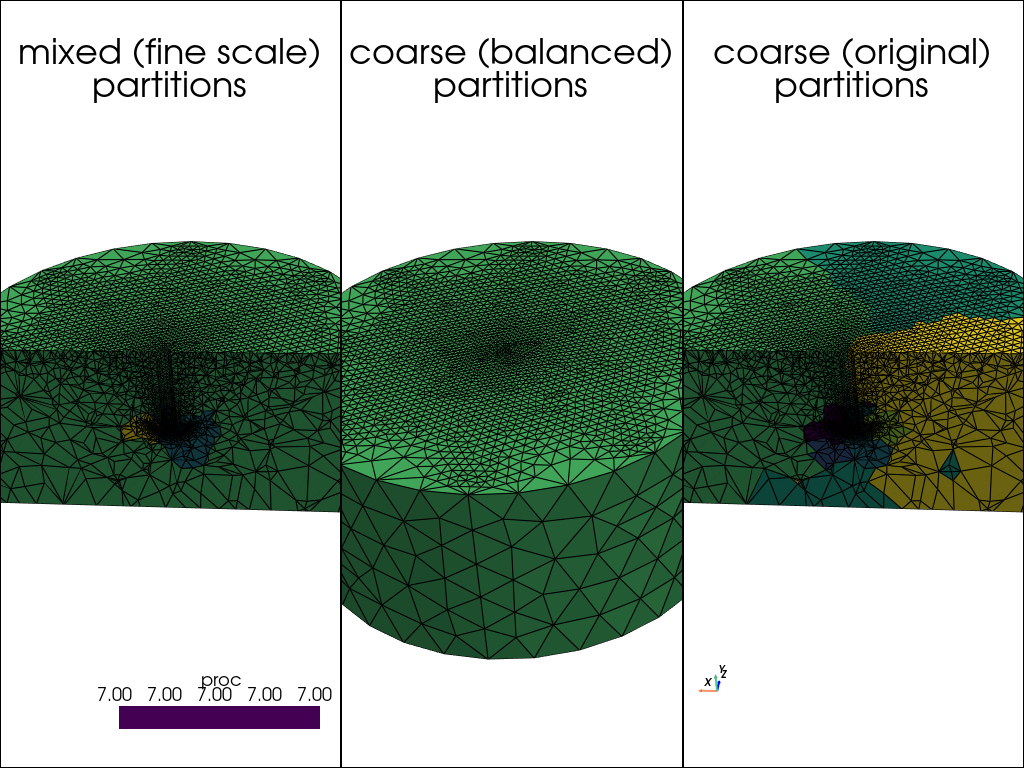

In [21]:
#nopy
plt=pv.Plotter(shape=(1, 3))
plt.subplot(0, 0)
for i in range(0,nw):
    plt.add_mesh(view['clippedf'][i],**pvoptp)
plt.add_title("mixed (fine scale)\npartitions",font_size=15)
plt.camera_position = camera_position
plt.subplot(0, 1)
for i in range(0,nw):
    plt.add_mesh(view['gridc'][i],**pvoptp)
plt.add_title("coarse (balanced)\npartitions",font_size=15)
plt.camera_position = camera_position
plt.subplot(0, 2)
for i in range(0,nw):
    plt.add_mesh(view['clippedo'][i],**pvoptp)
plt.add_title("coarse (original)\npartitions",font_size=15)
plt.add_axes()
plt.camera_position = camera_position
plt.link_views()
plt.show()

In [22]:
%%px
sub1=mesh.create_submesh(cdomain,dim,j.getSupport)
sub2=mesh.create_submesh(cdomain,dim,j.getSurroundingCells)
sub3=mesh.create_submesh(cdomain,dim,np.hstack((j.getSupport,j.getSurroundingCells)))
gridsub1=util.par_rank(sub1[0])
gridsub2=util.par_rank(sub2[0])
gridsub3=util.par_rank(sub3[0])
with io.VTXWriter(MPI.COMM_WORLD, "PO_extended_support.bp", sub3[0]) as ofile:
    ofile.write(0.)
master_grid=util.rootMasterFace(j,cdomain)


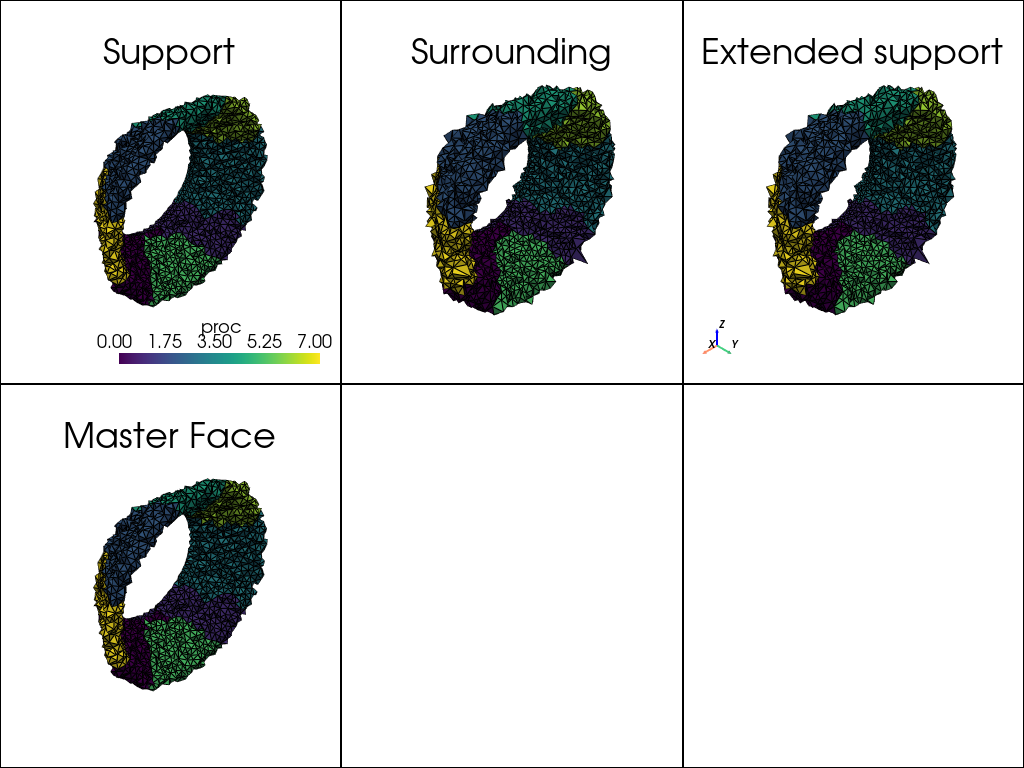

In [23]:
#nopy
plt=pv.Plotter(shape=(2, 3))
plt.subplot(0, 0)
for i in range(nw):
    plt.add_mesh(view['gridsub1'][i],**pvoptp)
plt.add_title("Support",font_size=15)
plt.subplot(0, 1)
for i in range(nw):
    plt.add_mesh(view['gridsub2'][i],**pvoptp)
plt.add_title("Surrounding",font_size=15)
plt.subplot(0, 2)
for i in range(nw):
    plt.add_mesh(view['gridsub3'][i],**pvoptp)
plt.add_title("Extended support",font_size=15)
plt.add_axes()
plt.link_views()
plt.subplot(1,0)
plt.add_mesh(view['master_grid'][0],**pvoptp)
plt.add_title("Master Face",font_size=15)

plt.show()

## Fine scale discretisation

### Space

In [24]:
%%px
space = fem.functionspace(fdomain, fdomain.ufl_domain().ufl_coordinate_element())

### Lamè

In [25]:
%%px
E=26400.00
nu=0.193
mu=fem.Constant(fdomain,E / (2.0 * (1.0 + nu)))
lmbda = fem.Constant(fdomain,E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu)))


### Damage

In [26]:
%%px
sp=0.8/(grow*grow)
lp=0.2
def profile(d):
    return (1.-d/grow+sp*d*(grow-d)*np.exp(-d*lp))

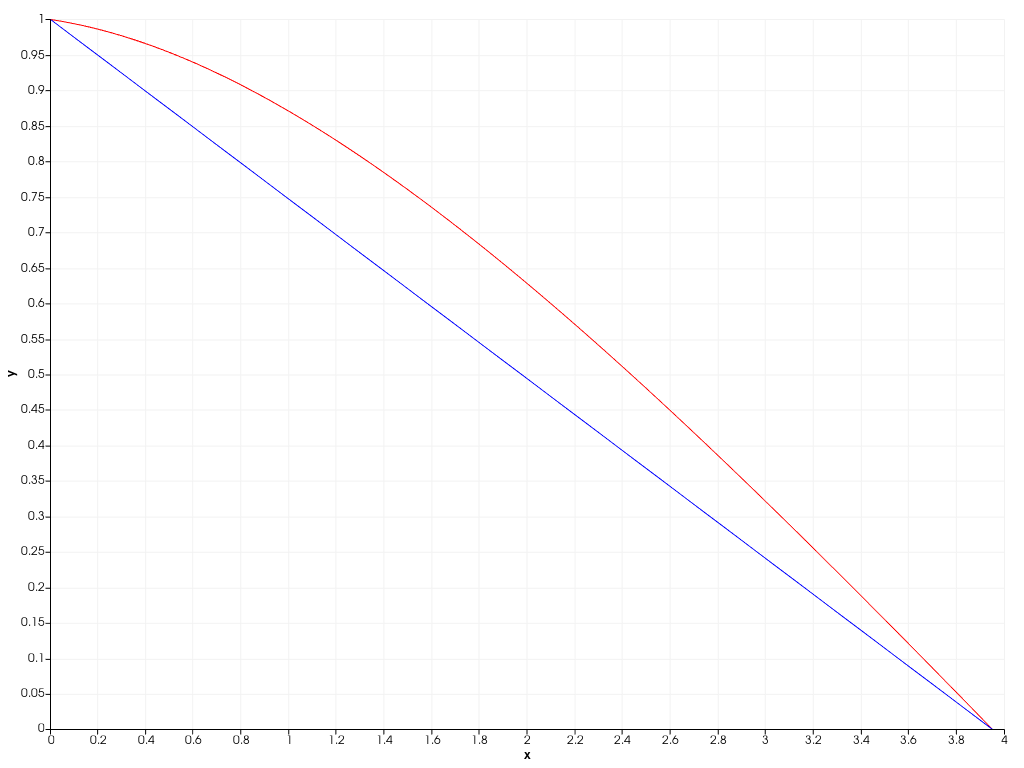

In [27]:
#nopy
grow=view['grow'][0]
sp=view['sp'][0]
lp=view['lp'][0]
def profile(d):
    return 1.-d/grow+sp*d*(grow-d)*np.exp(-d*lp)
x = np.linspace(0, grow, 200)
prof=pv.Chart2D()
prof.line(x,profile(x), color='r')
prof.line(x,1.-x/grow)
prof.show()

In [28]:
%%px
def dam(coords):
    r=np.sqrt(coords[0]*coords[0]+coords[2]*coords[2])
    ho=(ho1+ho2)/2
    test=np.logical_and(
        np.logical_not(np.logical_or(coords[1]>h2,coords[1]<h1)),
        np.logical_and(
            (tga*(coords[1]-ho1)-r)>0.,
            (r-tga*(coords[1]-ho2))>0.))
    yc=(coords[1]-ho+r*tga)*cosa2+ho
    return np.where(test,profile(np.sqrt(np.power(coords[1]-yc,2)+np.power(r-(yc-ho)*tga,2))),0)


In [29]:
%%px
element_scal = basix.ufl.element("Lagrange", "tetrahedron", 1)
space_scal = fem.functionspace(fdomain, element_scal)
space_scalc = fem.functionspace(cdomain, element_scal)
d=fem.Function(space_scal,name="d")
d.interpolate(dam)
dc=fem.Function(space_scalc,name="dc")
dc.interpolate(dam)

In [30]:
%%px
#nopy
damf=util.par_field(d,1.)
damc=util.par_field(dc,1.)
clippeddf = damf.clip('-z', [0.,0.,0.])
clippeddc = damc.clip('-z', [0.,0.,0.])

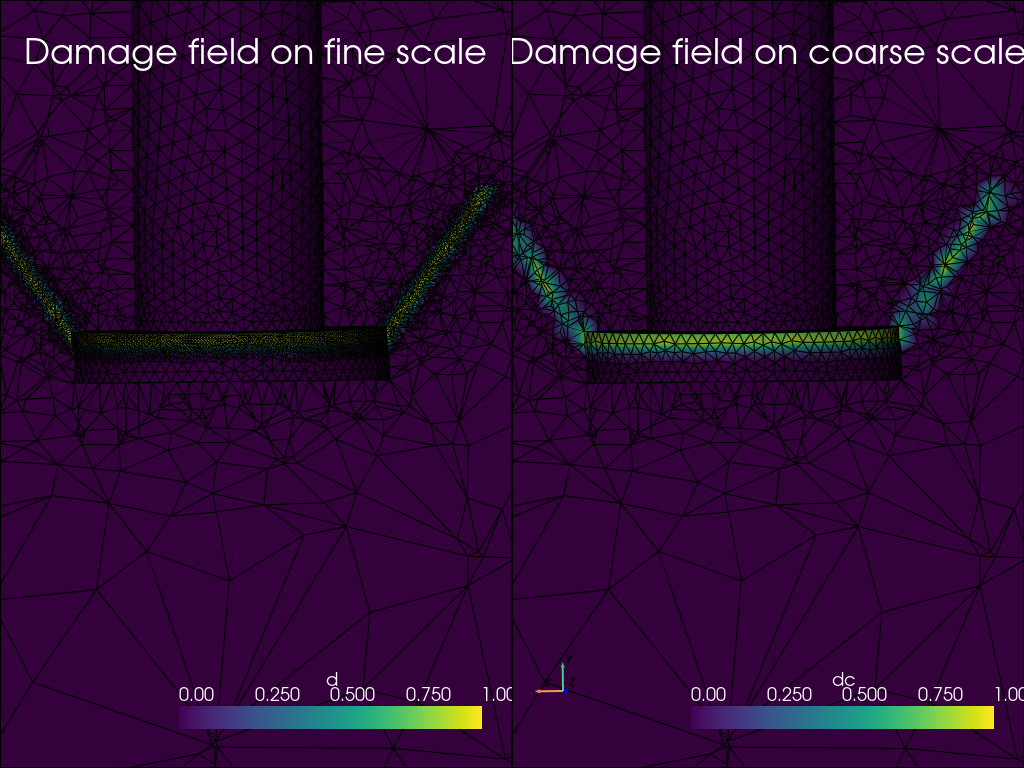

In [31]:
#nopy
plt=pv.Plotter(shape=(1,2))
plt.subplot(0, 0)
for i in range(nw):
    plt.add_mesh(view['clippeddf'][i],**pvoptpw)
plt.add_title("Damage field on fine scale",font_size=15,color='white')
plt.camera_position = camera_positiondam
plt.subplot(0,1)
for i in range(nw):
    plt.add_mesh(view['clippeddc'][i],**pvoptpw)
plt.add_title("Damage field on coarse scale",font_size=15,color='white')
plt.camera_position = camera_positiondam
plt.add_axes()
plt.link_views()
plt.show()

In [32]:
%%px
with io.VTXWriter(MPI.COMM_WORLD, "PO_dam.bp", [d]) as ofile:
    ofile.write(0.)
with io.VTXWriter(MPI.COMM_WORLD, "PO_dam_c.bp", [dc]) as ofile:
    ofile.write(0.)

### Formulation

#### Bilinear form

In [33]:
%%px
u = ufl.TrialFunction(space)
v = ufl.TestFunction(space)

In [34]:
%%px
def eps(v):
    return 0.5*(ufl.grad(v) + ufl.grad(v).T)

In [35]:
%%px
def sigma(strain): 
    return (1-d)*(2.0*mu*strain + lmbda*ufl.tr(strain)*ufl.Identity(dim))

In [36]:
%%px
a_ufl=ufl.inner(sigma(eps(u)), eps(v)) * ufl.dx

#### Surfacic load

Define ds to integrate  surface loading

In [37]:
%%px
r2=(dh/2)**2
small=0.00001
reducer2=1.5
if deri_load:
    r2=r2/reducer2
load_faces=mesh.locate_entities(fdomain, 2, lambda x: np.logical_and(np.logical_and(x[1]-px+hef<=small,x[1]-px+hef>=-small),
                                                                    x[0]*x[0]+x[2]*x[2]-r2<=small))

In [38]:
%%px
sub=mesh.create_submesh(fdomain,2,load_faces)
gridsub=util.par_rank(sub[0])

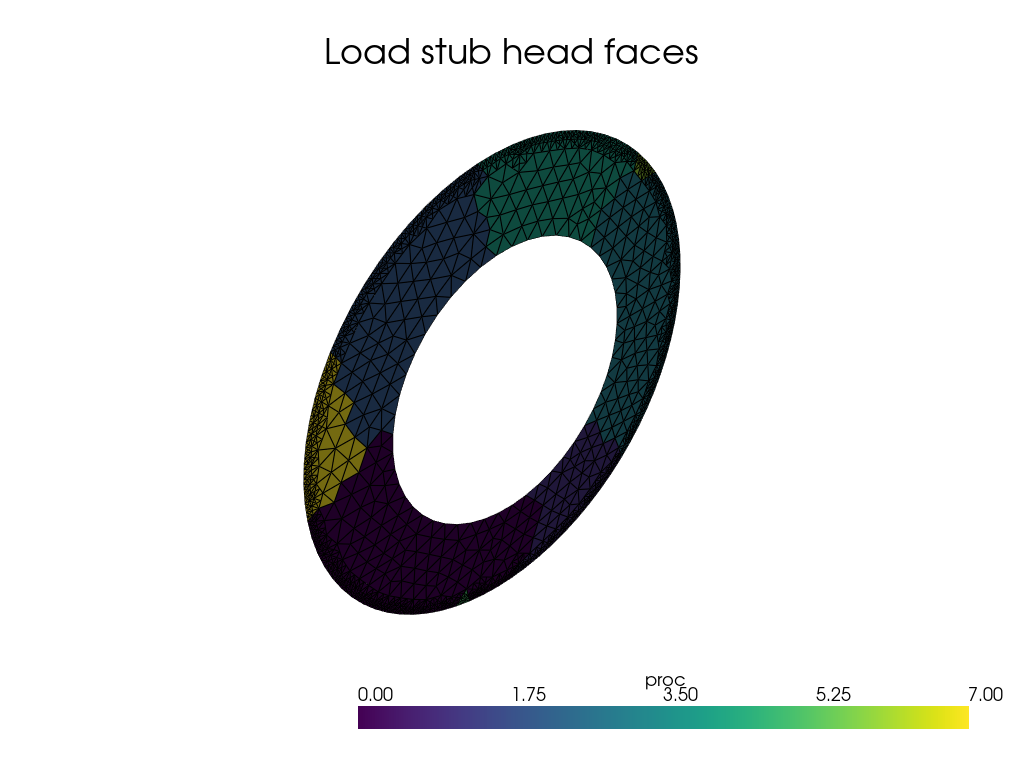

In [39]:
#nopy
plt=pv.Plotter()
for i in range(nw):
    plt.add_mesh(view['gridsub'][i],**pvoptp)
plt.add_title("Load stub head faces",font_size=15)
#plt.camera_position = 'xz'
plt.show()

In [40]:
%%px
facet_markers = np.full_like(load_faces, 100,dtype=np.int32)
sorted_facets = np.argsort(load_faces)
nfacets_tag = mesh.meshtags(
        fdomain, 2, load_faces[sorted_facets], facet_markers
    )
ds = ufl.Measure("ds", domain=fdomain, subdomain_data=nfacets_tag) 


Define load in y direction on surface under stub head

In [41]:
%%px
if deri_load:
    tload=0.
else:
    tload=load
stuby=fem.Constant(fdomain,[0.,tload,0.])
b_ufl=ufl.inner(stuby,v)*ds(100)


In [42]:
%%px
if deri_load:
    load_dofs=fem.locate_dofs_topological(space.sub(1),2,load_faces)
    bc_load=fem.dirichletbc(imp,load_dofs,space.sub(1))

### Dirichelet

Support clamped in  y direction

In [43]:
%%px
def locate_support(teta,dom):
    cs = np.cos(teta)
    si = np.sin(teta)
    lower = dhef-a/2
    up = dhef+a/2
    c2 = c/2.
    support_face=mesh.locate_entities(dom, 2, lambda x: np.logical_and(x[1]==py,
                                                            np.logical_and(np.logical_and(si*x[0]-cs*x[2]+c2>=-small,si*x[0]-cs*x[2]-c2<=small),
                                                            np.logical_and(cs*x[0]+si*x[2]-lower>=-small,cs*x[0]+si*x[2]-up<=small))))
    return support_face
delta = np.pi/4.;
support_faces=np.empty(0,dtype=np.int32)
for k in range(8):
    teta = k*delta+delta
    support_faces=np.concatenate((support_faces,locate_support(teta,fdomain)))

In [44]:
%%px
sub=mesh.create_submesh(fdomain,2,support_faces)
gridsub=util.par_rank(sub[0])

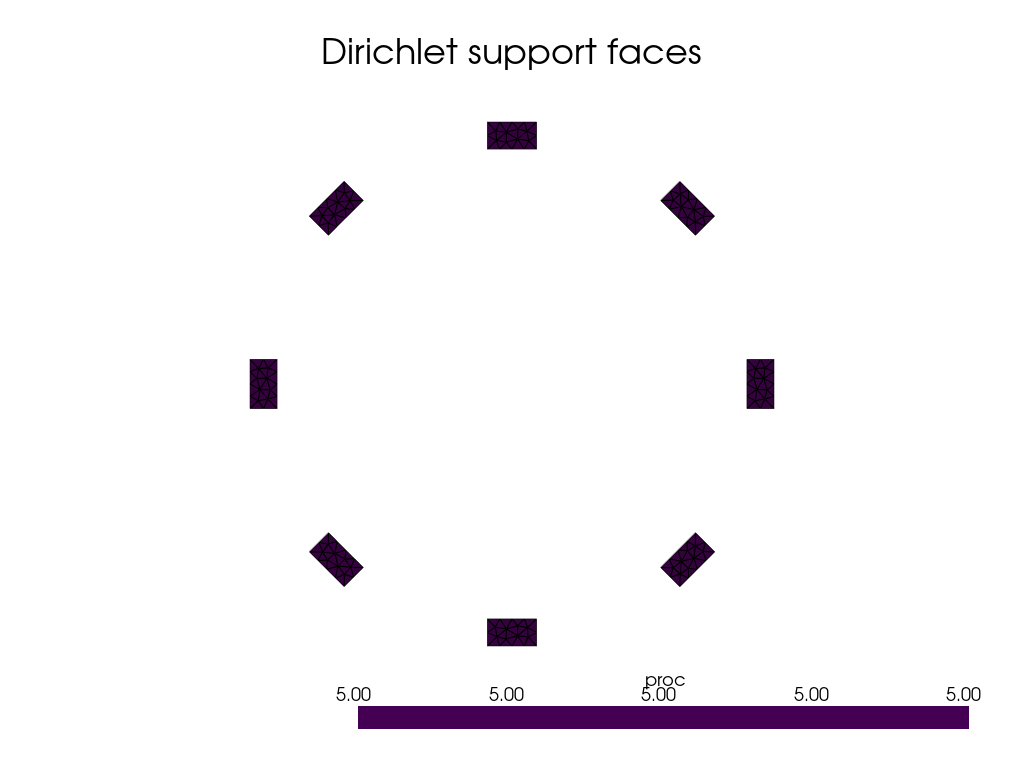

In [45]:
#nopy
plt=pv.Plotter()
for i in range(nw):
    plt.add_mesh(view['gridsub'][i],**pvoptp)
plt.add_title("Dirichlet support faces",font_size=15)
plt.camera_position = 'xz'
plt.show()

In [46]:
%%px
support_dofs=fem.locate_dofs_topological(space.sub(1),2,support_faces)
bc_support=fem.dirichletbc(0.,support_dofs,space.sub(1))

stub cylindar clamped in x,z direction

In [47]:
%%px
r2=(d0/2)**2
#dd=hef+h2
dd=0
if deri_load:
    r2=r2/reducer2
stub_faces=mesh.locate_entities(fdomain, 2, lambda x: np.logical_and(np.logical_and(x[1]<=small,x[1]-px+hef-dd>=-small),
                                                                    x[0]*x[0]+x[2]*x[2]-r2<=small))

In [48]:
%%px
sub=mesh.create_submesh(fdomain,2,stub_faces)
gridsub=util.par_rank(sub[0])
with io.VTXWriter(MPI.COMM_WORLD, "PO_stubxz.bp", sub[0]) as ofile:
    ofile.write(0.)

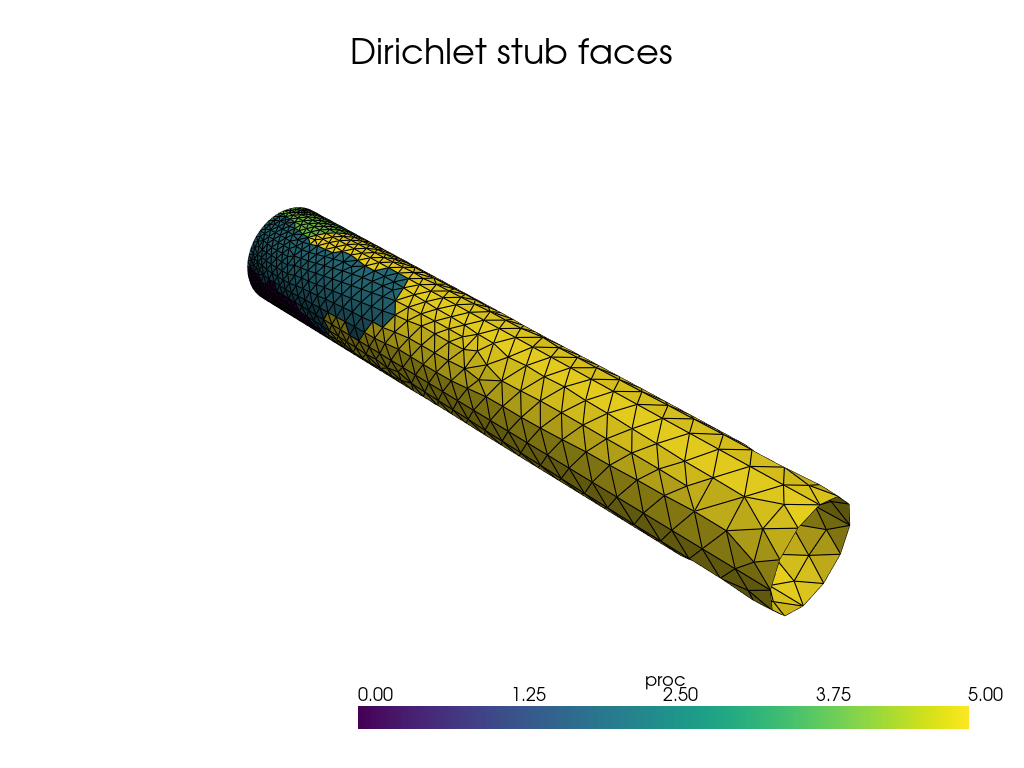

In [49]:
#nopy
plt=pv.Plotter()
for i in range(nw):
    plt.add_mesh(view['gridsub'][i],**pvoptp)
plt.add_title("Dirichlet stub faces",font_size=15)
plt.show()

In [50]:
%%px
stub1_x_dofs=fem.locate_dofs_topological(space.sub(0),2,stub_faces)
bc_stub1_x=fem.dirichletbc(0.,stub1_x_dofs,space.sub(0))
stub1_z_dofs=fem.locate_dofs_topological(space.sub(2),2,stub_faces)
bc_stub1_z=fem.dirichletbc(0.,stub1_z_dofs,space.sub(2))
#stub2_x_dofs=fem.locate_dofs_topological(space.sub(0),2,facets_tag.find(400))
#bc_stub2_x=fem.dirichletbc(0.,stub1_x_dofs,space.sub(0))
#stub2_z_dofs=fem.locate_dofs_topological(space.sub(2),2,facets_tag.find(400))
#bc_stub2_z=fem.dirichletbc(0.,stub1_z_dofs,space.sub(2))


Dirichlet is all condition above

In [51]:
%%px
if deri_load:
    bcs=[bc_support,bc_stub1_x,bc_stub1_z,bc_load]
else:
    bcs=[bc_support,bc_stub1_x,bc_stub1_z]
#bcs=[bc_support,bc_stub1_x,bc_stub1_z,bc_stub2_x,bc_stub2_z]

### mpc

In [52]:
%%px
mpc=core.generateMPC(j,space)

### Solve with direct resolution

In [53]:
%%px
#problem = petsc.LinearProblem(a_ufl, b_ufl,bcs=bcs,petsc_options=petsc_options)
problem = LinearProblem_mpc(a_ufl, b_ufl,mpc,bcs=bcs,petsc_options=petsc_options)

In [54]:
%%px
dt=common.Timer("Fine solve")
dt.start()
disp = problem.solve()
dt.stop()
del problem

In [55]:
%%px
disp.name="displacements"

In [56]:
%%px
warpf=util.par_field(disp,scale)
clippedwf = warpf.clip('-z', [0.,0.,0.])

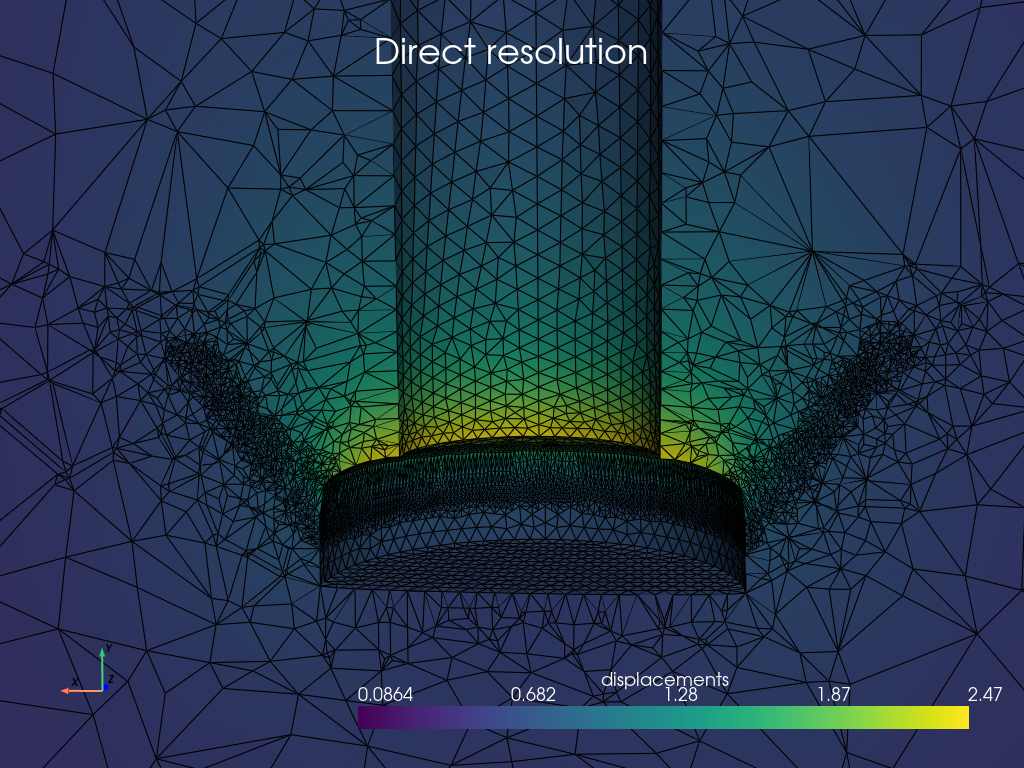

In [57]:
#nopy
plt=pv.Plotter()
for i in range(nw):
    plt.add_mesh(view['clippedwf'][i],**pvoptpw)
plt.add_title("Direct resolution",font_size=15,color='white')
plt.add_axes()
plt.camera_position = [(-33.0238996678173, -354.60971081475634, -386.6175118462205),
 (49.764908472958275, -465.79163270141413, 466.73312098224534),
 (0.002783776868024144, 0.9916497049175196, 0.12893065315643742)]

plt.show()

In [58]:
print(plt.camera_position)

[(-33.0238996678173, -354.60971081475634, -386.6175118462205),
 (49.764908472958275, -465.79163270141413, 466.73312098224534),
 (0.002783776868024144, 0.9916497049175196, 0.12893065315643742)]


In [59]:
%%px
with io.VTXWriter(MPI.COMM_WORLD, "PO_disp_direct.bp", [disp]) as ofile:
    ofile.write(0.)


## Twoscale approach

In [60]:
%%px --local
nested_strategy=core.useNest()


In [61]:
if nested_strategy:
    print("Use nested strategy")
else:
    print("Use monolithic strategy")

Use nested strategy


### Enriched space
If nested strategy enriched space is just standard space. Otherwise enriched space is a mixed space.

In [62]:
%%px
if nested_strategy:
    std=fem.functionspace(cdomain, cdomain.ufl_domain().ufl_coordinate_element())
else:
    el_mixed = basix.ufl.mixed_element([cdomain.ufl_domain().ufl_coordinate_element(), cdomain.ufl_domain().ufl_coordinate_element()])
    coarse_enriched_space = fem.functionspace(cdomain, el_mixed)

    std_=coarse_enriched_space.sub(0)
    std, std_to_mix=std_.collapse()
    enr_=coarse_enriched_space.sub(1)
    enr, enr_to_mix=enr_.collapse()
    std_to_mix_np=np.array(std_to_mix,dtype=int)

    disp_ce=fem.Function(coarse_enriched_space,name='disp_coarse_enriched')


### Solve coarse non enriched problem (standard part) to init two scale loop

#### Formulation

In [63]:
%%px
muc=fem.Constant(cdomain,E / (2.0 * (1.0 + nu)))
lmbdac = fem.Constant(cdomain,E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu)))
uc = ufl.TrialFunction(std)
vc = ufl.TestFunction(std)
def sigmac(strain): 
    return (1-dc)*(2.0*muc*strain + lmbdac*ufl.tr(strain)*ufl.Identity(dim))
ac_ufl=ufl.inner(sigmac(eps(uc)), eps(vc)) * ufl.dx

In [64]:
%%px
r2=(dh/2)**2
load_facesc=mesh.locate_entities(cdomain, 2, lambda x: np.logical_and(np.logical_and(x[1]-px+hef<=small,x[1]-px+hef>=-small),x[0]*x[0]+x[2]*x[2]-r2<=small))
facet_markersc = np.full_like(load_facesc, 100,dtype=np.int32)
sorted_facetsc = np.argsort(load_facesc)
nfacets_tagc = mesh.meshtags(
        cdomain, 2, load_facesc[sorted_facetsc], facet_markersc
    )
dsc = ufl.Measure("ds", domain=cdomain, subdomain_data=nfacets_tagc) 

In [65]:
%%px
stubyc=fem.Constant(cdomain,[0.,tload,0.])
dsx = ufl.Measure("ds", domain=cdomain, subdomain_data=nfacets_tagc)
bc_ufl=ufl.inner(stubyc,vc)*dsc(100)


#### Dirichelet

In [66]:
%%px
support_facesc=np.empty(0,dtype=np.int32)
for k in range(8):
    teta = k*delta+delta
    support_facesc=np.concatenate((support_facesc,locate_support(teta,cdomain)))
r2=(d0/2)**2
stub_facesc=mesh.locate_entities(cdomain, 2, lambda x: np.logical_and(np.logical_and(x[1]<=small,x[1]-px+hef-dd>=-small),
                                                                    x[0]*x[0]+x[2]*x[2]-r2<=small))

In [67]:
%%px
support_dofsc=fem.locate_dofs_topological(std.sub(1),2,support_facesc)
bc_supportc=fem.dirichletbc(0.,support_dofsc,std.sub(1))
stub1c_x_dofsc=fem.locate_dofs_topological(std.sub(0),2,stub_facesc)
bc_stub1c_x=fem.dirichletbc(0.,stub1c_x_dofsc,std.sub(0))
stub1c_z_dofs=fem.locate_dofs_topological(std.sub(2),2,stub_facesc)
bc_stub1c_z=fem.dirichletbc(0.,stub1c_z_dofs,std.sub(2))

if deri_load:
    load_dofsc=fem.locate_dofs_topological(std.sub(1),2,load_facesc)
    bc_loadc=fem.dirichletbc(imp,load_dofsc,std.sub(1))
    bcsc=[bc_supportc,bc_stub1c_x,bc_stub1c_z,bc_loadc]
else:
    bcsc=[bc_supportc,bc_stub1c_x,bc_stub1c_z]

#### Resolution

In [68]:
%%px
problemc = petsc.LinearProblem(ac_ufl, bc_ufl,bcs=bcsc,petsc_options=petsc_options)
dispc = problemc.solve()
dispc.name="disp_coarse"

In [69]:
%%px
#nopy
warpc=util.par_field(dispc,scale)
clippedc = warpc.clip('-z', [0.,0.,0.])

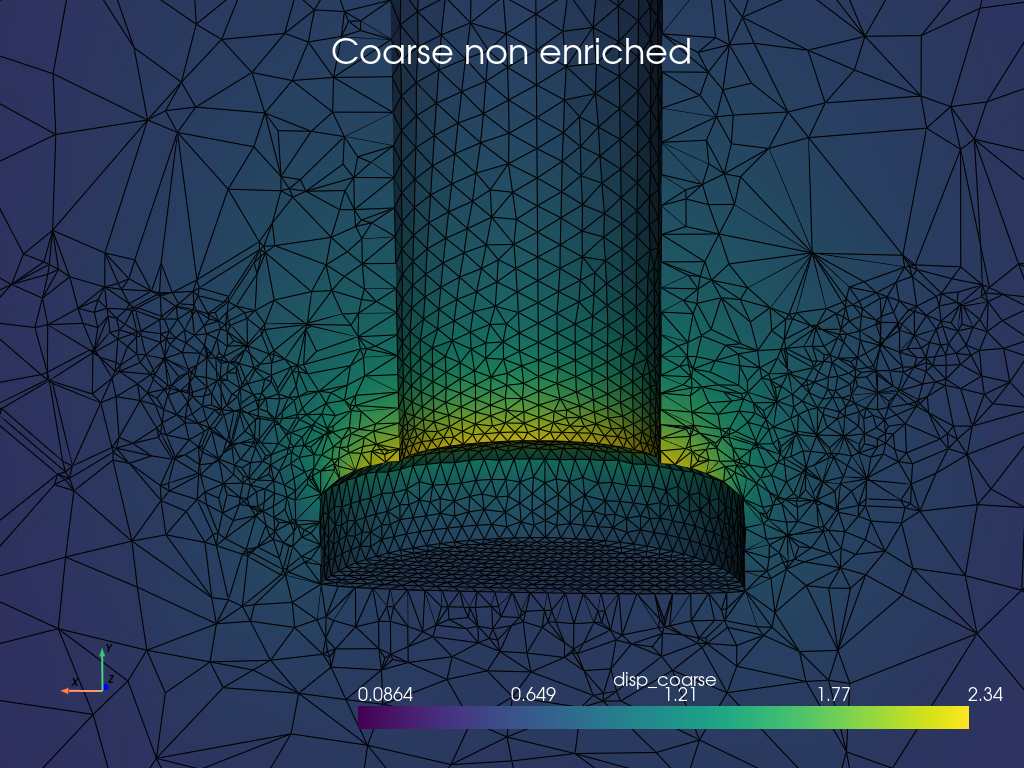

In [70]:
#nopy
plt=pv.Plotter()
for i in range(nw):
    plt.add_mesh(view['clippedc'][i],**pvoptpw)
plt.add_title("Coarse non enriched",font_size=15,color='white')
plt.camera_position = [(-33.0238996678173, -354.60971081475634, -386.6175118462205),
 (49.764908472958275, -465.79163270141413, 466.73312098224534),
 (0.002783776868024144, 0.9916497049175196, 0.12893065315643742)]
plt.add_axes()
plt.show()

In [71]:
%%px
with io.VTXWriter(MPI.COMM_WORLD, "PO_disp_coarse_ini.bp", [dispc]) as ofile:
    ofile.write(0.)


#### Store coarse standard in coarse enriched field

In [72]:
%%px 
if nested_strategy:
    disp_ce=dispc
else:
    disp_ce.x.array[std_to_mix_np]=dispc.x.array
#   print(disp_ce.x.array)

### Twoscale loop

#### Chose an enriched function

In [73]:
%%px
enriched_shift=core.generateEnrichedShiftFunction(disp)

#### resolution with linearBasicLoop (i.e. scale loop resolution)

Dirichlet boundary condition must be defined on mixed space and merged into one Dirichlet BC object for non nested strategy

In [74]:
%%px
if nested_strategy:
    BC_ce=bcsc
else:
    support_dofsc=std_to_mix_np[support_dofsc]
    stub1c_x_dofsc=std_to_mix_np[stub1c_x_dofsc]
    stub1c_z_dofs=std_to_mix_np[stub1c_z_dofs]
    if deri_load:
        load_dofsc=std_to_mix_np[load_dofsc]
    all_BC_values=fem.Function(coarse_enriched_space)
    if deri_load:
        all_BC_dof=np.concat((support_dofsc,stub1c_x_dofsc,stub1c_z_dofs,load_dofsc))
        all_BC_values.x.array[load_dofsc]=imp
    else:
        all_BC_dof=np.concat((support_dofsc,stub1c_x_dofsc,stub1c_z_dofs))
    all_BC_dof.sort()
    BC_ce=[fem.dirichletbc(all_BC_values,all_BC_dof)]

System are created and TS resolution is done considering Dirichlet BC imposed at patch level:

In [75]:
%%px 
[A,AD,BND,BD]=util.createFineScaleSytems(a_ufl,b_ufl,bcs=bcs,MPC=mpc)


In [76]:
%%px 
dt=common.Timer("TS solve")
dt.start()
[dispf, ra,nm, it,hrb,hrr]=linear.linearBasicLoop(j,space,A,AD,BND,BD,enriched_shift,disp_ce,mpc,BC_ce,itmax,epsr)
dt.stop()

Out[6:59]: 42.59

Out[7:59]: 42.6

Out[1:59]: 42.6

Out[4:59]: 42.59

Out[0:59]: 42.61

Out[2:59]: 42.6

Out[5:59]: 42.6

Out[3:59]: 42.63

In [77]:
%%px 
dt=common.Timer("TS solve Eimp")
dt.start()
[dispf3, ra3,nm3, it3,hrb3,hrr3]=linear.linearBasicLoopEimp(j,space,A,AD,BND,BD,enriched_shift,disp_ce,mpc,BC_ce,10,itmax,epsr)
dt.stop()

Out[6:60]: 57.400000000000006

Out[7:60]: 57.42

Out[5:60]: 57.42

Out[1:60]: 57.42

Out[4:60]: 57.43000000000001

Out[0:60]: 57.440000000000005

Out[2:60]: 57.440000000000005

Out[3:60]: 57.480000000000004

In [78]:
%%px
if fdomain.comm.rank==0:
    np.savez("PO_ts.npz",hrb=np.array(hrb),hrr=np.array(hrr))

## Results
### Displacement
Solutions with direct solver and TS solver are plotted bellow with theire differences

In [79]:
%%px
with io.VTXWriter(MPI.COMM_WORLD, "PO_disp_TS.bp", [dispf]) as ofile:
    ofile.write(0.)


In [80]:
%%px
#nopy
warpts=util.par_field(dispf,scale)
clippedts = warpts.clip('-z', [0.,0.,0.])
ddisp=fem.Function(space,name='diff_disp_fine')
ddisp.x.array[:]=disp.x.array-dispf.x.array
warpds=util.par_field(ddisp,1.e7,1)
clippedds = warpds.clip('-z', [0.,0.,0.])


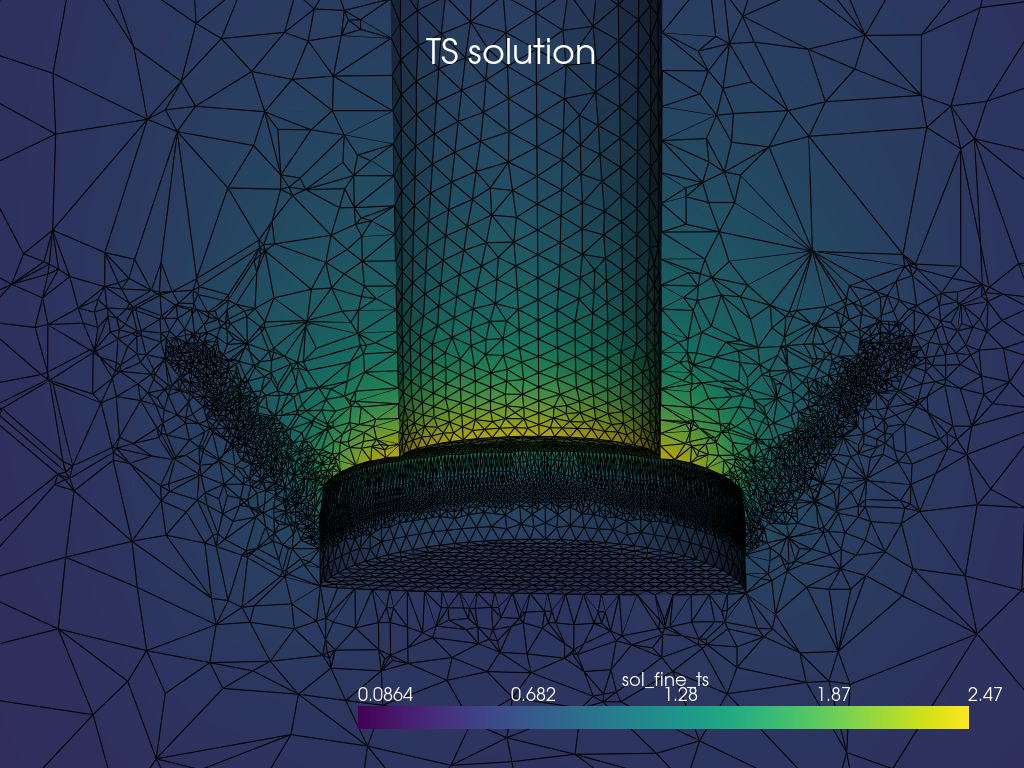

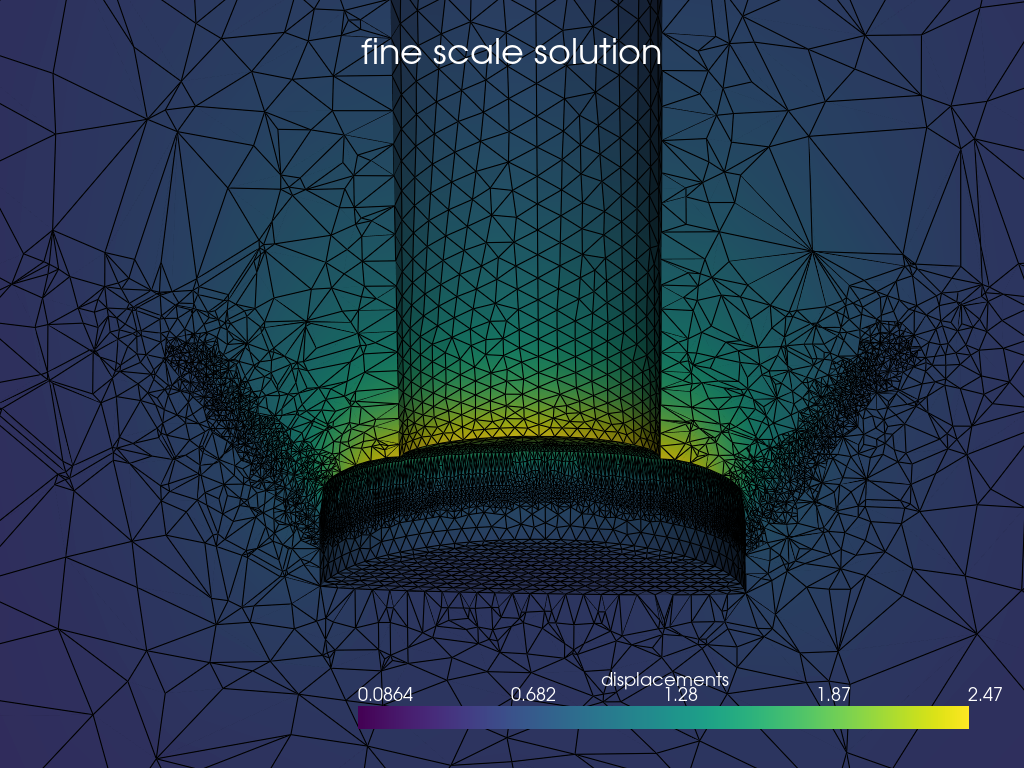

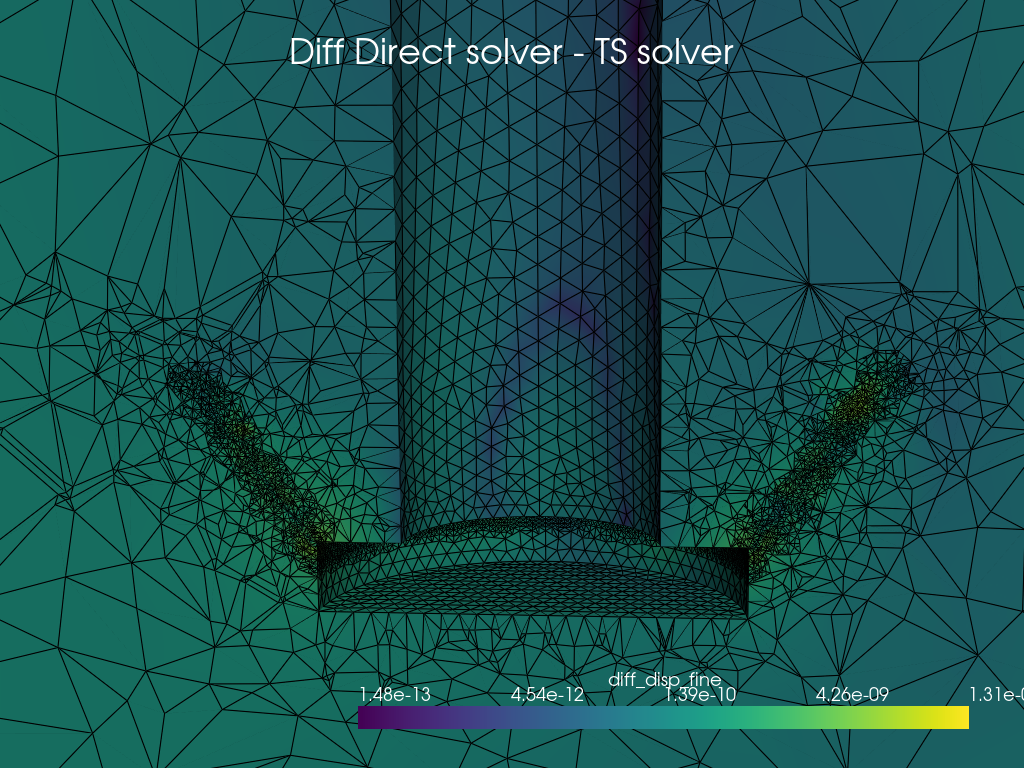

In [81]:
#nopy
camera_positiondisp = [(-33.0238996678173, -354.60971081475634, -386.6175118462205),
 (49.764908472958275, -465.79163270141413, 466.73312098224534),
 (0.002783776868024144, 0.9916497049175196, 0.12893065315643742)]
plt=pv.Plotter()
for i in range(0,nw):
    plt.add_mesh(view['clippedts'][i],**pvoptpw)
plt.add_title("TS solution",font_size=14,color='white')
plt.camera_position=camera_positiondisp
plt.show()

plt=pv.Plotter()
for i in range(0,nw):
    plt.add_mesh(view['clippedwf'][i],**pvoptpw)
plt.add_title("fine scale solution",font_size=14,color='white')
plt.camera_position=camera_positiondisp
plt.show()

plt=pv.Plotter()
for i in range(0,nw):
    plt.add_mesh(view['clippedds'][i],show_edges=True, show_scalar_bar=True, log_scale=True, copy_mesh=True,scalar_bar_args={"color": "white",})
plt.add_title("Diff Direct solver - TS solver",font_size=14,color='white')
plt.camera_position=camera_positiondisp
plt.show()


### convergence

Text(0, 0.5, 'Relative residual')

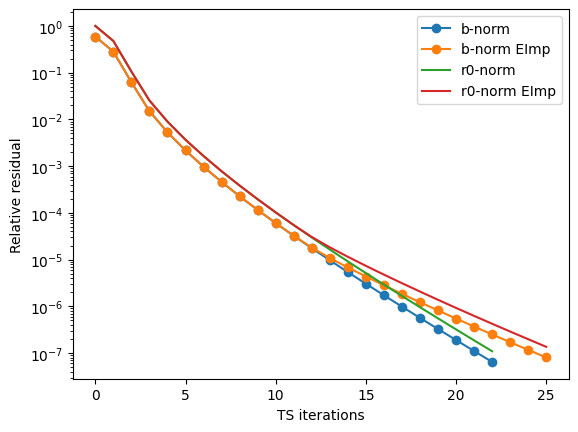

In [82]:
#nopy
import matplotlib.pyplot as mplt
mplt.plot(view['hrb'][0],'o-',label='b-norm')
mplt.plot(view['hrb3'][0],'o-',label='b-norm EImp')
mplt.plot(view['hrr'][0],label='r0-norm')
mplt.plot(view['hrr3'][0],label='r0-norm EImp')
mplt.legend()
mplt.yscale('log')
mplt.xlabel('TS iterations')
mplt.ylabel('Relative residual')

### Residual

In [83]:
%%px
Rf=fem.Function(space)
R=Rf.x.petsc_vec
AD.mult(dispf.x.petsc_vec,R)
with io.VTXWriter(MPI.COMM_WORLD, "PO_Ax.bp", [Rf]) as ofile:
    ofile.write(0.)
R.aypx(-1.,BD)
with io.VTXWriter(MPI.COMM_WORLD, "PO_Axb.bp", [Rf]) as ofile:
    ofile.write(0.)


## video



In [84]:
%%px
#nopy
[dispfv, r, it,pm,cm,hrb,hrr,hds]=linear.linearBasicLoopVideo("PO.gif",scale,j,disp.function_space,A,AD,BND,BD,enriched_shift,disp_ce,mpc,BC_ce,itmax,epsr,None,patch=False)


[stdout:0] At twoscale iteration 0 residual is 0.5910222721886301(b) 1.(r) 1.(ds)
At twoscale iteration 1 residual is 0.2816299962544677(b) 0.47651333884856195(r) 0.07553055014976795(ds)
At twoscale iteration 2 residual is 0.06251403193363851(b) 0.10577271767126668(r) 0.014900066431402605(ds)
At twoscale iteration 3 residual is 0.015027994449228584(b) 0.025427120358050167(r) 0.002057706656086269(ds)
At twoscale iteration 4 residual is 0.005304651070938736(b) 0.008975382689547288(r) 0.0005455883303826798(ds)
At twoscale iteration 5 residual is 0.0021662969076530645(b) 0.003665338870616489(r) 0.00019807656883422814(ds)
At twoscale iteration 6 residual is 0.0009732303564592294(b) 0.0016466898156904212(r) 8.034360186751716e-05(ds)
At twoscale iteration 7 residual is 0.00045980338475946875(b) 0.0007779797926341401(r) 3.4641116599365894e-05(ds)
At twoscale iteration 8 residual is 0.00022696498744742186(b) 0.0003840210396927037(r) 1.5544114380123173e-05(ds)
At twoscale iteration 9 residual is

In [85]:
%%px
#nopy
pvopt={"show_edges":True, "show_scalar_bar":True}
patch_field=fem.Function(mpc.function_space,name='patches')


```{image} PO.gif
:width: 600px
:align: center
```


## Statistic

In [86]:
#nopy
del plt

In [87]:
%%px
common.list_timings(MPI.COMM_WORLD,[common.TimingType.wall, common.TimingType.user])
petsc4py.PETSc.Log.view()

[stdout:0] ****************************************************************************************************************************************************************
***                                WIDEN YOUR WINDOW TO 160 CHARACTERS.  Use 'enscript -r -fCourier9' to print this document                                 ***
****************************************************************************************************************************************************************

------------------------------------------------------------------ PETSc Performance Summary: ------------------------------------------------------------------

Unknown Name on a  named xxxxxxxxxxxxxxxxxxxxx with 8 processes, by salzman on xxxxxxxxxxxxxxxxxxx 2026
Using Petsc Release Version 3.22.2, unknown 

                         Max       Max/Min     Avg       Total
Time (sec):           2.345e+02     1.000   2.345e+02
Objects:              0.000e+00     0.000   0.000e+00
Flops:                

In [88]:
from pathlib import Path
from IPython.display import display, Markdown

text = Path("proc_0_output.txt").read_text()

marker = "[MPI_MAX] Summary of timings"
idx = text.find(marker)

if idx != -1:
    display(Markdown(f"```text\n{text[idx:]}\n```"))
else:
    print(f"'{marker}' not found")


```text
[MPI_MAX] Summary of timings                                                |  reps    usr avg    usr tot   wall avg   wall tot
-------------------------------------------------------------------------------------------------------------------------------
Build dofmap data                                                           |    24   0.005000   0.120000   0.004583   0.110000
Build sparsity                                                              |     1   0.010000   0.010000   0.010000   0.010000
Compute Node weighted graph partition (ParMETIS)                            |     1   0.040000   0.040000   0.030000   0.030000
Compute connectivity 0-0                                                    |     3   0.000000   0.000000   0.000000   0.000000
Compute connectivity 1-0                                                    |     2   0.000000   0.000000   0.000000   0.000000
Compute connectivity 2-0                                                    |     4   0.005000   0.020000   0.002500   0.010000
Compute connectivity 3-0                                                    |     1   0.000000   0.000000   0.000000   0.000000
Compute dof reordering map                                                  |    24   0.000833   0.020000   0.000833   0.020000
Compute entities of dim = 1                                                 |     4   0.055000   0.220000   0.057500   0.230000
Compute entities of dim = 2                                                 |     5   0.032000   0.160000   0.032000   0.160000
Compute entity permutations                                                 |     2   0.015000   0.030000   0.010000   0.020000
Compute graph partition (ParMETIS)                                          |     2   0.020000   0.040000   0.015000   0.030000
Compute local part of mesh dual graph (mixed)                               |     9   0.018889   0.170000   0.024444   0.220000
Compute local-to-local map                                                  |     6   0.001667   0.010000   0.000000   0.000000
Compute non-local part of mesh dual graph                                   |     3   0.006667   0.020000   0.006667   0.020000
Compute-local-to-global links for global/local adjacency list               |     6   0.001667   0.010000   0.000000   0.000000
Distribute fixed-degree adjacency list to destination ranks                 |     3   0.006667   0.020000   0.006667   0.020000
Distribute row-wise data (scalable)                                         |     6   0.001667   0.010000   0.000000   0.000000
Fine solve                                                                  |     1   7.750000   7.750000  10.600000  10.600000
GPS: create_level_structure                                                 |    56   0.001143   0.040000   0.000571   0.020000
Gibbs-Poole-Stockmeyer ordering                                             |    11   0.005714   0.040000   0.005714   0.040000
Init dofmap from element dofmap                                             |    24   0.002500   0.060000   0.002917   0.070000
PLAZA: Enforce rules                                                        |     2   0.010000   0.020000   0.000000   0.000000
PLAZA: refine                                                               |     2   0.050000   0.100000   0.045000   0.090000
ParMETIS: call ParMETIS_V3_PartKway                                         |     3   0.023333   0.070000   0.020000   0.060000
SparsityPattern::finalize                                                   |    12   0.035833   0.430000   0.036667   0.440000
TS solve                                                                    |     1  41.100000  41.100000  42.630000  42.630000
TS solve Eimp                                                               |     1  54.740000  54.740000  57.480000  57.480000
Topology: create                                                            |     6   0.053333   0.320000   0.056667   0.340000
Topology: determine shared index ownership                                  |     6   0.026667   0.160000   0.031667   0.190000
Topology: determine vertex ownership groups (owned, undetermined, unowned)  |     6   0.003333   0.020000   0.003333   0.020000
~MPC: Apply lifting (C++)                                                   |     2   0.005000   0.010000   0.005000   0.010000
~MPC: Assemble matrix (C++)                                                 |     3   0.636667   1.910000   0.643333   1.930000
~MPC: Assemble vector (C++)                                                 |     3   0.000000   0.000000   0.000000   0.000000
~MPC: Create new index map with additional ghosts                           |     1   0.010000   0.010000   0.010000   0.010000
~MPC: Create sparsity pattern                                               |     2   0.030000   0.060000   0.035000   0.070000
~MPC: Create sparsity pattern (Classic)                                     |     2   0.010000   0.020000   0.010000   0.020000

```